In [8]:
import os

def count_images_per_subdir(root_dir):
  """Counts the number of images in each subdirectory of a given directory.

  Args:
    root_dir: The path to the root directory.

  Returns:
    A dictionary where keys are subdirectory names and values are the number of images in each subdirectory.
  """

  image_counts = {}
  for subdir, _, files in os.walk(root_dir):
    image_count = 0
    for file in files:
      if file.lower().endswith(('.png', '.jpg', '.jpeg')):
        image_count += 1
    if image_count > 0:  # Only include subdirectories with images.
      subdir_name = os.path.basename(subdir)
      image_counts[subdir_name] = image_count
  return image_counts


# Example usage:
train_dir = 'fer2013-data/train'
test_dir = 'fer2013-data/test'

train_image_counts = count_images_per_subdir(train_dir)
test_image_counts = count_images_per_subdir(test_dir)

print("Number of images in each subdirectory of 'train':")
for subdir, count in train_image_counts.items():
  print(f"{subdir}: {count}")

print("\nNumber of images in each subdirectory of 'test':")
for subdir, count in test_image_counts.items():
  print(f"{subdir}: {count}")

Number of images in each subdirectory of 'train':
angry: 3984
fear: 4090
happy: 7204
neutral: 4954
sad: 4827
surprise: 3165

Number of images in each subdirectory of 'test':
angry: 956
fear: 1023
happy: 1772
neutral: 1231
sad: 1246
surprise: 829


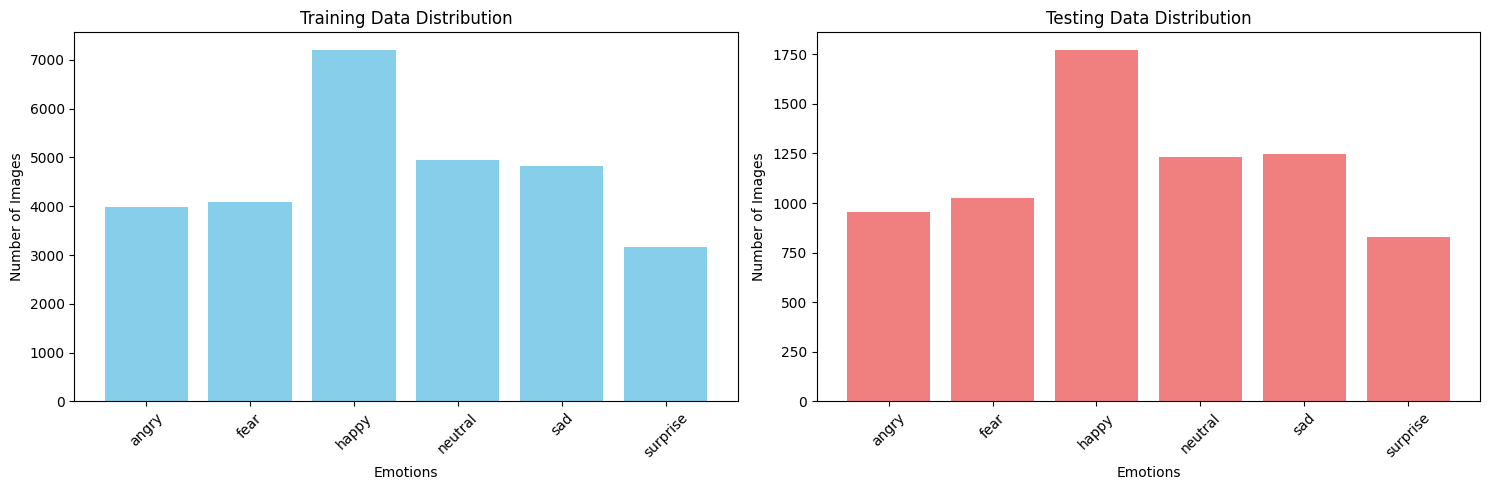

In [9]:
import matplotlib.pyplot as plt

# Prepare data for plotting
emotions_train = list(train_image_counts.keys())
counts_train = list(train_image_counts.values())

emotions_test = list(test_image_counts.keys())
counts_test = list(test_image_counts.values())

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot histogram for training data
axes[0].bar(emotions_train, counts_train, color='skyblue')
axes[0].set_title('Training Data Distribution')
axes[0].set_xlabel('Emotions')
axes[0].set_ylabel('Number of Images')
axes[0].tick_params(axis='x', rotation=45) # Rotate x-axis labels for better readability


# Plot histogram for testing data
axes[1].bar(emotions_test, counts_test, color='lightcoral')
axes[1].set_title('Testing Data Distribution')
axes[1].set_xlabel('Emotions')
axes[1].set_ylabel('Number of Images')
axes[1].tick_params(axis='x', rotation=45) # Rotate x-axis labels


plt.tight_layout()
plt.show()

In [ ]:
import os

# Hàm xoá ảnh dựa trên dictionary đầu vào
def delete_images(images_dict):
    """
    Hàm nhận một dictionary làm đầu vào và xoá các tệp ảnh được liệt kê trong dictionary.
    
    :param images_dict: Dictionary với key là đường dẫn thư mục, value là danh sách các tệp ảnh cần xoá.
    """
    for folder, images in images_dict.items():
        for image in images:
            image_path = os.path.join(folder, image)
            try:
                os.remove(image_path)
                print(f"Đã xoá: {image_path}")
            except OSError as e:
                print(f"Lỗi khi xoá {image_path}: {e}")

# Tạo dictionary làm đầu vào
dump_image_train = {
    'fer2013-data/train/angry': [
        'Training_5645946.jpg',
        'Training_10131352.jpg',
        'Training_22407840.jpg',
        'Training_25739285.jpg',
        'Training_28756096.jpg',
        'Training_32571770.jpg',
        'Training_99531165.jpg',
        'Training_96772745.jpg',
        'Training_87875595.jpg',
        'Training_67604214.jpg',
        'Training_52563817.jpg'
    ],
    'fer2013-data/train/fear': [
        'Training_1018372.jpg',
        'Training_2167967.jpg',
        'Training_75260133.jpg',
        'Training_19304002.jpg',
        'Training_53028968.jpg',
        'Training_62764355.jpg',
        'Training_65365689.jpg'
    ],
    'fer2013-data/train/happy': [
        'Training_71811.jpg',
        'Training_9150638.jpg',
        'Training_13969968.jpg',
        'Training_19441677.jpg',
        'Training_30373500.jpg',
        'Training_33313497.jpg',
        'Training_56742561.jpg',
        'Training_59324777.jpg',
        'Training_62231267.jpg',
        'Training_79595939.jpg',
        'Training_91720745.jpg'
    ],
    'fer2013-data/train/neutral':[
        'Training_7927893.jpg',
        'Training_29529460.jpg',
        'Training_35406373.jpg',
        'Training_38142836.jpg',
        'Training_42279539.jpg',
        'Training_44094885.jpg',
        'Training_66880865.jpg',
        'Training_75186221.jpg',
        'Training_88342086.jpg',
        'Training_89335926.jpg',
        'Training_99019653.jpg'
    ],
    'fer2013-data/train/sad':[
        'Training_28055108.jpg',
        'Training_75787895.jpg',
        'Training_87857337.jpg'
    ],
    'fer2013-data/train/surprise':[
        'Training_3951286.jpg',
        'Training_10264146.jpg',
        'Training_19197283.jpg',
        'Training_48403842.jpg',
        'Training_86145739.jpg',
        'Training_96848455.jpg'
    ]
}


dump_image_test = {
    'fer2013-data/test/angry':[
        'PrivateTest_26784100.jpg',
        'PublicTest_5543497.jpg'
    ],
    'fer2013-data/test/fear':[
        'PrivateTest_65872116.jpg'
    ],
    'fer2013-data/test/happy':[
        'PublicTest_21832858.jpg',
        'PublicTest_97297069.jpg'
    ],
    'fer2013-data/test/neutral':[
        'PrivateTest_1844176.jpg',
        'PrivateTest_15353271.jpg'
    ],
    'fer2013-data/test/sad':[
        'PublicTest_83014731.jpg'
    ],
    'fer2013-data/test/surprise':[
        'PrivateTest_57200649.jpg',
        'PublicTest_53795000.jpg'
    ]
}

# Gọi hàm để xoá ảnh
delete_images(dump_image_train)
delete_images(dump_image_test)

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch import nn, optim
import matplotlib.pyplot as plt




# Định nghĩa biến device để kiểm tra GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print(f"GPU có sẵn: {torch.cuda.get_device_name(0)}")
else:
    print("Không có GPU hoặc CUDA không được cài đặt.")

# Định nghĩa các phép biến đổi hình ảnh cho huấn luyện và kiểm tra
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomRotation(degrees=5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])



# Tải dữ liệu huấn luyện và kiểm tra
train_data = datasets.ImageFolder(root='fer2013-data/train', transform=transform)
test_data = datasets.ImageFolder(root='fer2013-data/test',transform=transform)

# Dataloader cho huấn luyện và kiểm tra
train_loader = DataLoader(train_data, batch_size=64, num_workers=4, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, num_workers=4, shuffle=False)

# Kiểm tra số lớp trong mô hình (số lớp từ thư mục của bạn)
num_classes = len(train_data.classes)
print(f'Number of classes: {num_classes}')

GPU có sẵn: NVIDIA GeForce RTX 3060
Number of classes: 6


In [11]:
class ConvNet(nn.Module):
    def __init__(self, num_classes=6):
        super(ConvNet, self).__init__()

        # Block 1: Conv + BatchNorm + Conv + BatchNorm + MaxPool + Dropout
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 1 input channel (grayscale), 32 output channels
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        # Block 2: Conv + BatchNorm + Conv + BatchNorm + MaxPool + Dropout
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        # Block 3: Conv + BatchNorm + Conv + BatchNorm + MaxPool + Dropout
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2),
            nn.Dropout(0.3)
        )

        # Fully Connected Layers
        self.fc1 = nn.Linear(512 * 3 * 3, 256)  # Flatten the output from Conv layers (assuming input size 48x48)
        self.batch_norm_fc1 = nn.BatchNorm1d(256)
        self.dropout_fc1 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, num_classes)  # Output layer with `num_classes` neurons

    def forward(self, x):
        # Pass through each block of convolutional layers
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        # Flatten the output before passing to fully connected layers
        x = x.view(x.size(0), -1)  # Flatten the tensor
        
        # Pass through fully connected layers
        x = self.fc1(x)
        x = F.relu(x)
        x = self.batch_norm_fc1(x)
        x = self.dropout_fc1(x)
        x = self.fc2(x)

        return x

# Instantiate the model
model = ConvNet(num_classes=6)

Epoch [200/200], Loss: 0.06801810284681585 ------ Time:104.13170766830444


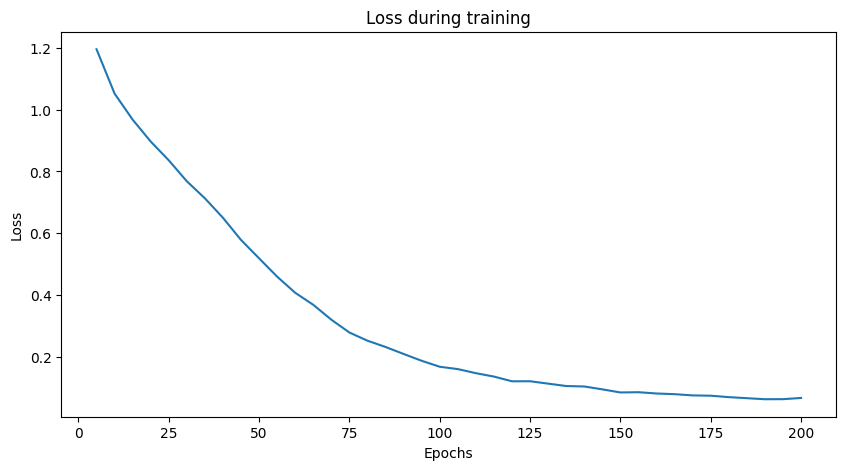

In [12]:
from IPython.display import clear_output
import torch.nn.functional as F
import time

model = model.to(device)  # Chuyển mô hình sang GPU nếu có

# optimizer = optim.Adam(model.parameters(), lr=0.01)
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
train_losses = []
# Huấn luyện mô hình
num_epochs = 200
for epoch in range(1,num_epochs+1):
    if epoch%5==1:
        start_time = time.time()
    model.train()  # Chế độ huấn luyện
    running_loss = 0.0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)  # Chuyển dữ liệu sang GPU

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Tính toán loss trung bình của epoch
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # In loss sau mỗi epoch
    
    
    # Vẽ biểu đồ loss sau mỗi epoch
    if epoch%5==0 :
        clear_output(wait=True)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {epoch_loss} ------ Time:{time.time()-start_time}')
        plt.figure(figsize=(10, 5))
        plt.plot(range(5, epoch+1,5),train_losses[4::5], label='Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Loss during training')
        plt.show()  # Cập nhật biểu đồ mà không cần vẽ lại từ đầu

In [13]:
from sklearn.metrics import classification_report

# Kiểm tra độ chính xác và in ra classification_report trên dữ liệu test
model.eval()  # Chế độ kiểm tra
y_true = []
y_pred = []

with torch.no_grad():  # Không tính gradient khi kiểm tra
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)  # Chuyển dữ liệu sang GPU
        output = model(data)
        _, predicted = torch.max(output.data, 1)
        
        y_true.extend(target.cpu().numpy())  # Lưu nhãn thực tế
        y_pred.extend(predicted.cpu().numpy())  # Lưu dự đoán

# In classification report
print(classification_report(y_true, y_pred, target_names=test_loader.dataset.classes))


              precision    recall  f1-score   support

       angry       0.63      0.60      0.61       956
        fear       0.53      0.51      0.52      1023
       happy       0.86      0.86      0.86      1772
     neutral       0.58      0.65      0.61      1231
         sad       0.54      0.53      0.53      1246
    surprise       0.80      0.79      0.80       829

    accuracy                           0.67      7057
   macro avg       0.66      0.65      0.66      7057
weighted avg       0.67      0.67      0.67      7057



In [14]:
torch.save(model.state_dict(), 'model67_sgd.pth')
print("Mô hình đã được lưu dưới tên 'model67_sgd.pth'")

Mô hình đã được lưu dưới tên 'model67_sgd.pth'


In [15]:
# Tạo mô hình
model = ConvNet(num_classes=6)

# Tải trọng số vào mô hình
model.load_state_dict(torch.load('model67_sgd.pth'))



<All keys matched successfully>

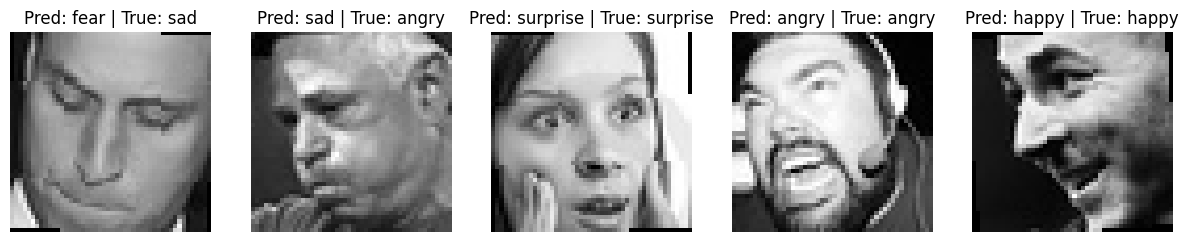

In [16]:
import matplotlib.pyplot as plt
import torch
import random
from torchvision import transforms
import numpy as np

# Đảm bảo mô hình ở chế độ kiểm tra
# Đảm bảo mô hình ở chế độ eval và chuyển sang GPU nếu có
model.eval()
model = model.to(device)  # Chuyển mô hình sang thiết bị (GPU/CPU)

# Chọn ngẫu nhiên một số ảnh từ test_loader
num_images = 5  # Số lượng ảnh bạn muốn hiển thị
random_indices = random.sample(range(len(test_loader.dataset)), num_images)

# Hiển thị các ảnh và kết quả dự đoán
fig, axes = plt.subplots(1, num_images, figsize=(15, 15))

for i, idx in enumerate(random_indices):
    image, label = test_loader.dataset[idx]  # Lấy ảnh và nhãn thực tế từ dataset
    
    # Chuyển ảnh vào GPU nếu đang sử dụng GPU
    image = image.unsqueeze(0).to(device)  # Thêm chiều batch và chuyển ảnh sang GPU (nếu có)

    # Dự đoán lớp của ảnh
    with torch.no_grad():
        output = model(image)
        _, predicted = torch.max(output.data, 1)  # Chọn lớp có xác suất cao nhất

    # Hiển thị ảnh và nhãn dự đoán
    axes[i].imshow(image.squeeze(0).cpu().numpy().transpose((1, 2, 0)), cmap='gray')  # Chuyển ảnh tensor về numpy array để hiển thị
    axes[i].set_title(f"Pred: {test_loader.dataset.classes[predicted.item()]} | True: {test_loader.dataset.classes[label]}")
    axes[i].axis('off')

plt.show()

